# Curve Preprocessing Walkthrough 

**Stages shown:**
1. Raw signal (pre-linearisation)
2. Linearised signal
3. Truncated + Rebaselined
4. Denoising -- Savitzky-Golay filter

In [ ]:
import os, sys, importlib.util, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb:
        os.chdir(os.path.dirname(os.path.dirname(os.path.dirname(_nb))))
except Exception:
    pass
sys.path.insert(0, os.getcwd())
sys.path.insert(0, 'utils')
sys.path.insert(0, 'utils/model_training')

%load_ext autoreload
%autoreload 2

_spec = importlib.util.spec_from_file_location(
    "chip_preprocessing", str(Path.cwd() / "chip" / "preprocessing.py"))
cp01 = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(cp01)
config = cp01.config

import linearise as linearise_mod

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.size': 10,
})
print("CWD:", os.getcwd())
print("Available POC_DDM_final experiments:",
      sorted(config.CROSS_DATASET_GROUPS['final_6_new']))



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

CWD: /vol/bitbucket/gk225/POC_DDM/main_code
Available POC_DDM_final experiments: ['D20260825_E00_C00_F4500KHz_U_DDM_05_01', 'D20260825_E00_C00_F4500KHz_U_DDM_06_02', 'D20260827_E00_C00_F4500KHz_U_DDM_01_final_final', 'D20260827_E00_C00_F4500KHz_U_DDM_02_final_final', 'D20260827_E00_C00_F4500KHz_U_DDM_03_final_final', 'D20260827_E00_C00_F4500KHz_U_DDM_04_final_final']


## SAMPLE

In [2]:
EXP_NAME = 'D20260827_E00_C00_F4500KHz_U_DDM_01_final_final'  # any name from the list printed above
exp_path = Path(config.FINAL_EXP_FOLDER) / EXP_NAME


In [3]:
_captured = []
_orig_linearise = linearise_mod.linearise
def _hooked_linearise(frame_3d, *args, **kwargs):
    raw_in = frame_3d.copy()
    out = _orig_linearise(frame_3d, *args, **kwargs)
    lin_out = out[0].copy() if isinstance(out, tuple) else out.copy()
    _captured.append((raw_in, lin_out))
    return out
linearise_mod.linearise = _hooked_linearise

t0 = time.perf_counter()
all_exp_data = cp01.load_and_preprocess_v6(
    exp_path, n_wells=config.N_WELLS, n_a_type=config.N_A_TYPE, vref_ref_idx='all')
linearise_mod.linearise = _orig_linearise  # unhook, one-shot capture is enough
print(f"\nLoaded in {time.perf_counter() - t0:.1f}s -- {len(all_exp_data)} vref slice(s), "
      f"{len(all_exp_data[0].wells_list)} wells")

raw_full, lin_full = _captured[0]  # full-chip (rows, cols, time), before the well split


[INFO] D20260827_E00_C00_F4500KHz_U_DDM_01_final_final: found 1 readout file(s). Processing...
Loaded vref sweep from 20260827T160301.89_vref_sweep.bin: n_vrefs=1
[INFO] Slice 1/1: DDM_01_final_final__vref_idx=0_vref=3010
EXP PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260827_E00_C00_F4500KHz_U_DDM_01_final_final 
VREF PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260827_E00_C00_F4500KHz_U_DDM_01_final_final/20260827T160301.89_vref_sweep.bin 
Load vref... 
Loaded vref list: n_vrefs=1, first=3010, last=3010
EXP PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260827_E00_C00_F4500KHz_U_DDM_01_final_final 
READOUT PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260827_E00_C00_F4500KHz_U_DDM_01_final_final/20260827T160344.08_readout_time.bin 
Load data... 
(290, 204, 1, 932)
Time vector: n=932, median_dt=3s, duration≈41.60min
(59160,)
new gain shape  (59160,)
(290, 204, 1, 932)
Data loaded. 
Preprocessing start...
Active pixel counts (re

In [4]:
WELL_ID = 0           # 0..9 (config.N_WELLS=10 wells per experiment)
well = all_exp_data[0].wells_list[WELL_ID]
local_rows, local_cols = well.well_3d_lin.shape[0], well.well_3d_lin.shape[1]

idx_active = np.asarray(well.idx_active)
active_positions = np.where(idx_active)[0]


In [5]:
PIXEL_SEED = 1        # picks a random *active* pixel within that well; change for a different curve
rng = np.random.default_rng(PIXEL_SEED)
pick_flat = int(rng.choice(active_positions))
local_r, local_c = np.unravel_index(pick_flat, (local_rows, local_cols), order='C')

row_group, col_group = WELL_ID // 2, WELL_ID % 2
global_r = row_group * local_rows + local_r
global_c = col_group * local_cols + local_c
print(f"well={WELL_ID}  local pixel=({local_r},{local_c})  global pixel=({global_r},{global_c})")


well=0  local pixel=(30,42)  global pixel=(30,42)


## Reconstruct the full batch + find 01's truncation index (MSI)

In [ ]:
X_time, Y_well, X_2d_bs_active = cp01.reconstruct_data(all_exp_data, attr_str="well_2d_bs_active")

active_rank = int(np.sum(idx_active[:pick_flat]))
offset = sum(int(np.sum(all_exp_data[0].wells_list[i].idx_active)) for i in range(WELL_ID))
row_idx = offset + active_rank
assert np.allclose(X_2d_bs_active[row_idx], well.well_2d_bs_active[:, np.sum(idx_active[:pick_flat])]), \
    "pixel row mapping is wrong -- fix before trusting downstream steps"
print(f"X_2d_bs_active shape: {X_2d_bs_active.shape}  (our pixel is row {row_idx})")


X_2d_bs_active shape: (18209, 896)  (our pixel is row 918)


In [7]:
from scipy.ndimage import uniform_filter1d

mapping = config.LABEL_MAPPINGS.get(EXP_NAME)
y_label = np.array([mapping.get(w, w) for w in Y_well]) if mapping is not None else None
pc_mask = (y_label == 'PC') if y_label is not None else np.zeros(len(Y_well), dtype=bool)

if np.any(pc_mask):
    smoothed = uniform_filter1d(np.mean(X_2d_bs_active[pc_mask], axis=0).squeeze(), size=20)
    max_significant_index = int(np.argmin(smoothed))
    print(f"[PC argmin] max_significant_index={max_significant_index} ({int(pc_mask.sum())} PC-well curves)")
else:
    ori_curve_dydx = np.array(cp01.get_derivatives(X_2d_bs_active, X_time))
    min_indices = np.argmin(ori_curve_dydx, axis=1)
    unique_indices, counts = np.unique(min_indices, return_counts=True)
    significant_indices = unique_indices[counts > (len(ori_curve_dydx) / 3)]
    max_significant_index = int(np.max(significant_indices)) if len(significant_indices) > 0 else None
    print(f"[Derivative vote] max_significant_index={max_significant_index}")


[PC argmin] max_significant_index=26 (1828 PC-well curves)


## 1-2. Raw and linearised

In [8]:
t_full = well.time_npr  # full, un-windowed experiment time axis (seconds)

steps = []  # list of (title, x, y) -- built up one stage at a time
steps.append(("1. Raw Signal", t_full, raw_full[global_r, global_c, :]))
steps.append(("2. Linearised", t_full, lin_full[global_r, global_c, :]))

msi_time = t_full[well.idx_settled + max_significant_index]
idx_end_time = t_full[min(well.idx_end, len(t_full) - 1)]
print(f"MSI marker at t={msi_time:.1f}s (idx_settled={well.idx_settled} + MSI={max_significant_index})")
print(f"idx_end marker at t={idx_end_time:.1f}s (idx_end={well.idx_end})")


MSI marker at t=161.0s (idx_settled=35 + MSI=26)
idx_end marker at t=2496.0s (idx_end=931)


## 3. Truncated + Rebaselined

In [ ]:
X_2d_trunc, t_trunc = X_2d_bs_active, t_full[well.idx_settled:well.idx_end]
if max_significant_index is not None and (max_significant_index + 1) < (len(X_time) - 100):
    X_2d_trunc = X_2d_bs_active[:, max_significant_index + 1:]
    t_trunc = t_trunc[max_significant_index + 1:]
t_trunc = t_trunc - t_trunc[0]

X_2d_trunc = X_2d_trunc - X_2d_trunc[:, 0:1]
X_2d_nc = X_2d_trunc.copy()

steps.append(("3. Truncated + Rebaselined", t_trunc, X_2d_nc[row_idx]))
print("Truncated shape:", X_2d_trunc.shape)


Truncated shape: (18209, 869)


## 4. Denoising -- Savitzky-Golay Filter


In [10]:
t0 = time.perf_counter()
sg_curves, opt_w = cp01.sg_p4_denoise_curves(X_2d_nc)
steps.append((f"4. Denoising - Savitzky-Golay Filter", t_trunc, sg_curves[row_idx]))
print(f"SG denoise done in {time.perf_counter() - t0:.1f}s")


SG denoise done in 4.3s


## Plot every stage

D20260827_E00_C00_F4500KHz_U_DDM_01_final_final  |  well 0  |  pixel (local 30,42 / global 30,42)


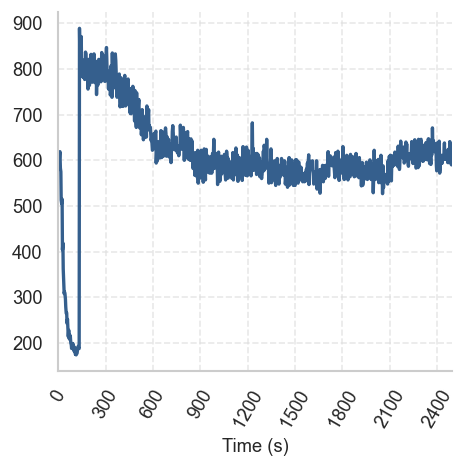

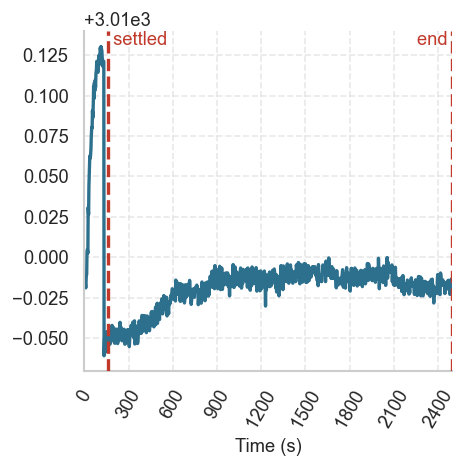

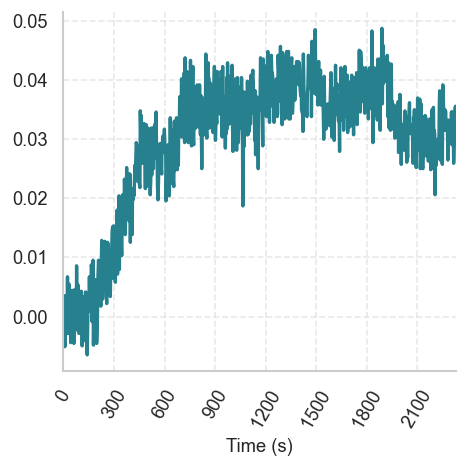

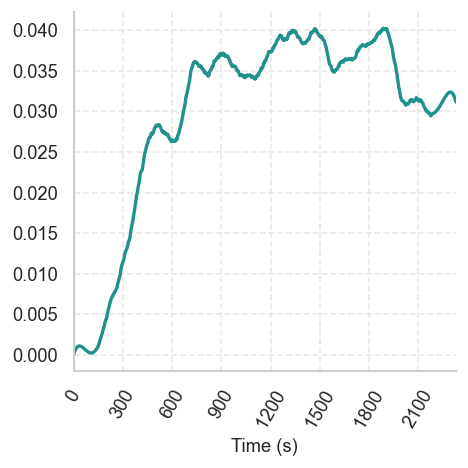

In [11]:
from matplotlib.ticker import MultipleLocator

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    # 'axes.grid': True,
    # 'grid.color': '#e0e0e0',
    # 'grid.linestyle': '--',
    # 'grid.alpha': 0.7,
    'font.size': 10,
})

print(f"{EXP_NAME}  |  well {WELL_ID}  |  pixel (local {local_r},{local_c} / "
      f"global {global_r},{global_c})")

colors = plt.cm.viridis(np.linspace(0.3, 0.5, len(steps)))

for i, ((title, x, y), color) in enumerate(zip(steps, colors)):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.plot(x, y, color=color, lw=2)
    # ax.set_title(title, fontsize=10.5, fontweight='bold', loc='left')
    ax.set_xlim(x[0], x[-1])
    ax.set_xlabel("Time (s)", fontsize=11)
    ax.tick_params(labelsize=11)
    ax.tick_params(axis='x', rotation=60)
    ax.xaxis.set_major_locator(MultipleLocator(300))
    if i == 1:  # linearised panel -- mark where MSI truncation and idx_end fall
        ylim = ax.get_ylim()
        ax.axvline(msi_time, color='#c0392b', lw=2, linestyle='--', zorder=5)
        ax.axvline(idx_end_time, color='#c0392b', lw=2, linestyle='--', zorder=5)
        ax.text(msi_time, ylim[1], ' settled', color='#c0392b', fontsize=11, va='top', ha='left')
        ax.text(idx_end_time, ylim[1], 'end ', color='#c0392b', fontsize=11, va='top', ha='right')
    fig.tight_layout()
    plt.show()


# Combined pipeline figure

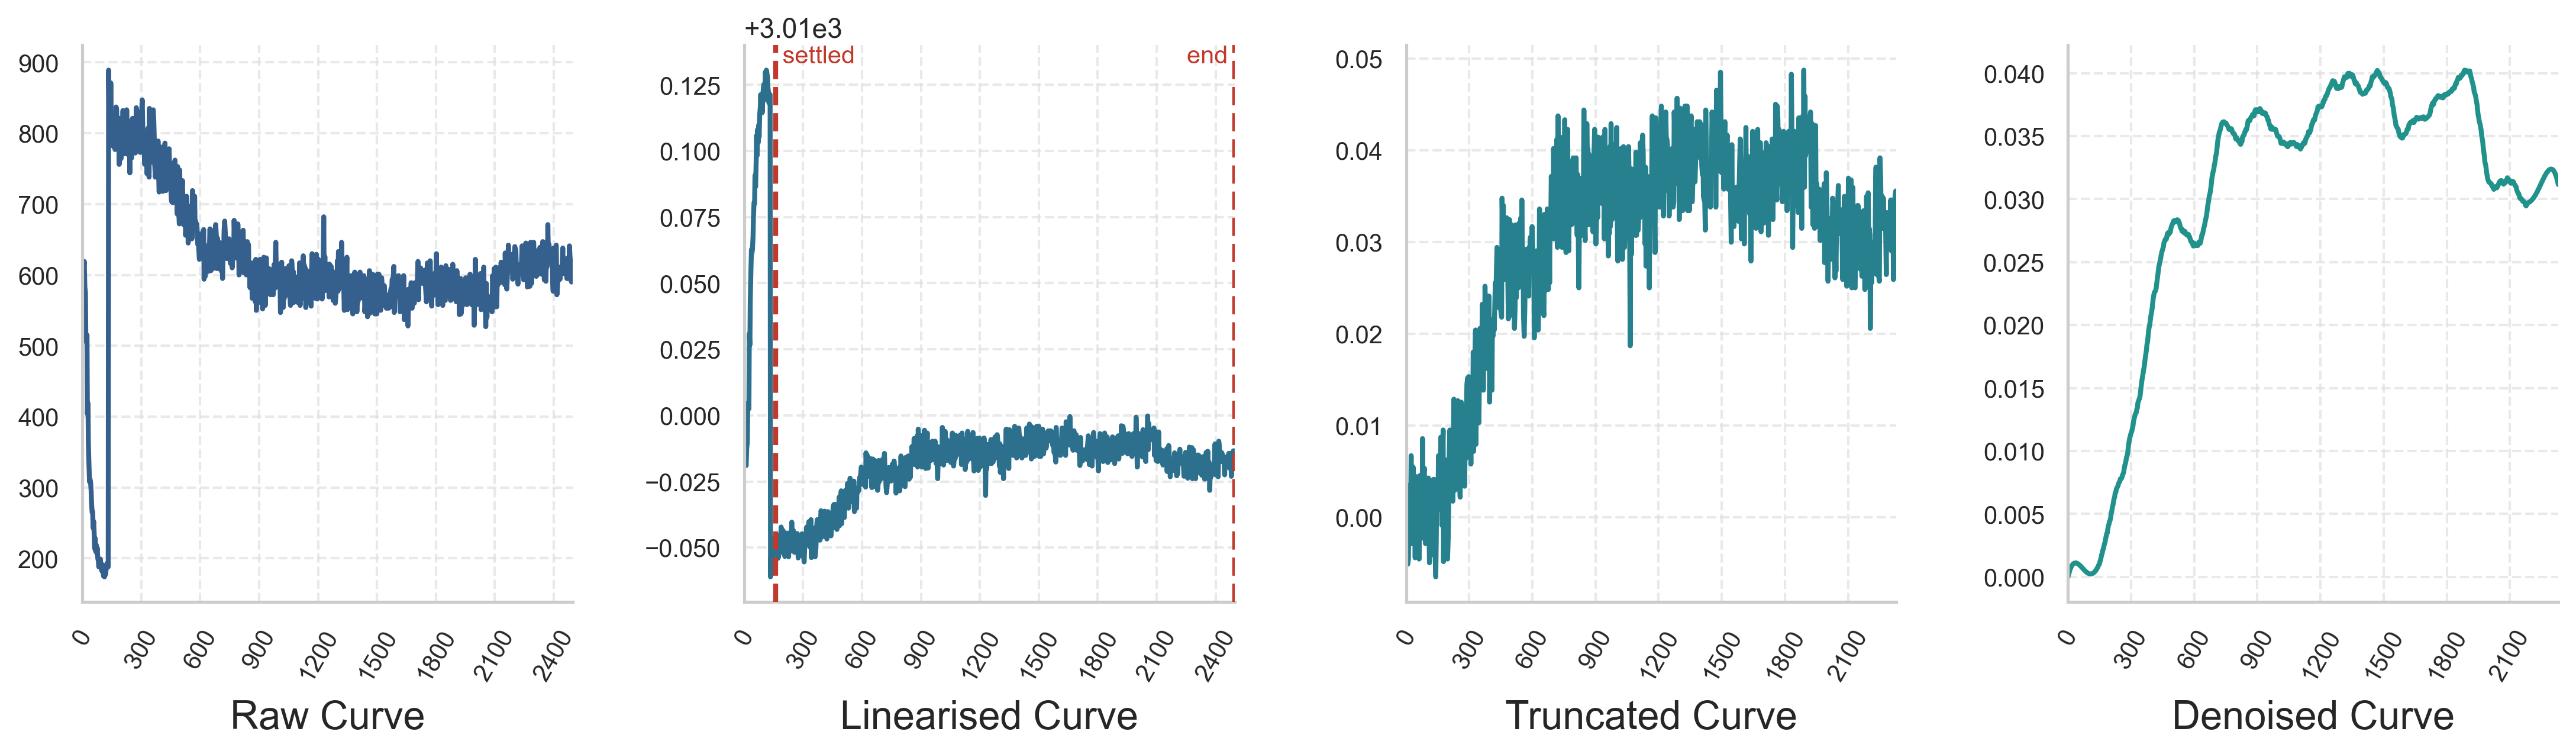

In [ ]:
panel_titles = ['Raw Curve', 'Linearised Curve', 'Truncated Curve', 'Denoised Curve']
colors = plt.cm.viridis(np.linspace(0.3, 0.5, len(steps)))

fig, axes = plt.subplots(1, len(steps), figsize=(4.5 * len(steps), 4.3), dpi=300)
fig.subplots_adjust(wspace=0.35, bottom=0.22, top=0.95)

for i, ((title, x, y), color, ax) in enumerate(zip(steps, colors, axes)):
    ax.plot(x, y, color=color, lw=2)
    ax.set_xlim(x[0], x[-1])
    ax.tick_params(labelsize=10)
    ax.tick_params(axis='x', rotation=60)
    ax.xaxis.set_major_locator(MultipleLocator(300))
    if i == 1:  # linearised panel -- mark where MSI truncation and idx_end fall
        ylim = ax.get_ylim()
        ax.axvline(msi_time, color='#c0392b', lw=2, linestyle='--', zorder=5)
        ax.axvline(idx_end_time, color='#c0392b', lw=2, linestyle='--', zorder=5)
        ax.text(msi_time, ylim[1], ' settled', color='#c0392b', fontsize=10, va='top', ha='left')
        ax.text(idx_end_time, ylim[1], 'end ', color='#c0392b', fontsize=10, va='top', ha='right')

fig.canvas.draw()  

renderer = fig.canvas.get_renderer()
for ax, label in zip(axes, panel_titles):
    pos = ax.get_position()
    tb  = ax.get_tightbbox(renderer).transformed(fig.transFigure.inverted())
    fig.text((pos.x0 + pos.x1) / 2, tb.y0 - 0.02, label, ha='center', va='top', fontsize=16)

SAVE_DIR = Path('figures')
SAVE_DIR.mkdir(exist_ok=True)
# save_path = SAVE_DIR / f'{EXP_NAME}_pipeline_stages.png'
# fig.savefig(save_path, dpi=300, facecolor='white')
# print(f"Saved high-res figure -> {save_path.resolve()}")
plt.show()


## Multi-chip pipeline comparison (LOFO group)

In [ ]:
from scipy.ndimage import uniform_filter1d
from chip import cross_dataset_training as cdt

LOFO_GROUP = 'final_6_new'
TARGET_LABEL = 'IAV'
chip_names = config.CROSS_DATASET_GROUPS[LOFO_GROUP]
print(f"LOFO_GROUP={LOFO_GROUP!r}  TARGET_LABEL={TARGET_LABEL!r}  ({len(chip_names)} chips)")
for name in chip_names:
    print(' ', name)

LOFO_GROUP='final_6_new'  TARGET_LABEL='IAV'  (6 chips)
  D20260827_E00_C00_F4500KHz_U_DDM_01_final_final
  D20260827_E00_C00_F4500KHz_U_DDM_02_final_final
  D20260827_E00_C00_F4500KHz_U_DDM_03_final_final
  D20260827_E00_C00_F4500KHz_U_DDM_04_final_final
  D20260825_E00_C00_F4500KHz_U_DDM_05_01
  D20260825_E00_C00_F4500KHz_U_DDM_06_02


In [14]:
def run_pixel_pipeline(exp_name, target_label, pixel_seed=1):
    exp_path = Path(config.FINAL_EXP_FOLDER) / exp_name

    _captured = []
    _orig_linearise = linearise_mod.linearise
    def _hooked_linearise(frame_3d, *args, **kwargs):
        raw_in = frame_3d.copy()
        out = _orig_linearise(frame_3d, *args, **kwargs)
        lin_out = out[0].copy() if isinstance(out, tuple) else out.copy()
        _captured.append((raw_in, lin_out))
        return out
    linearise_mod.linearise = _hooked_linearise
    all_exp_data = cp01.load_and_preprocess_v6(
        exp_path, n_wells=config.N_WELLS, n_a_type=config.N_A_TYPE, vref_ref_idx='all')
    linearise_mod.linearise = _orig_linearise
    raw_full, lin_full = _captured[0]

    X_time, Y_well, X_2d_bs_active = cp01.reconstruct_data(all_exp_data, attr_str="well_2d_bs_active")

    mapping = config.LABEL_MAPPINGS.get(exp_name)
    y_label = np.array([mapping.get(w, w) for w in Y_well]) if mapping is not None else Y_well
    matches = np.where(y_label == target_label)[0]
    if len(matches) == 0:
        raise ValueError(f"{exp_name}: no active pixel labelled {target_label!r} "
                         f"(available: {sorted(set(y_label))})")
    WELL_ID = int(Y_well[matches[0]])

    well = all_exp_data[0].wells_list[WELL_ID]
    local_rows, local_cols = well.well_3d_lin.shape[0], well.well_3d_lin.shape[1]
    idx_active = np.asarray(well.idx_active)
    active_positions = np.where(idx_active)[0]

    rng = np.random.default_rng(pixel_seed)
    pick_flat = int(rng.choice(active_positions))
    local_r, local_c = np.unravel_index(pick_flat, (local_rows, local_cols), order='C')
    row_group, col_group = WELL_ID // 2, WELL_ID % 2
    global_r = row_group * local_rows + local_r
    global_c = col_group * local_cols + local_c

    active_rank = int(np.sum(idx_active[:pick_flat]))
    offset = sum(int(np.sum(all_exp_data[0].wells_list[i].idx_active)) for i in range(WELL_ID))
    row_idx = offset + active_rank
    assert np.allclose(X_2d_bs_active[row_idx], well.well_2d_bs_active[:, np.sum(idx_active[:pick_flat])]), \
        "pixel row mapping is wrong -- fix before trusting downstream steps"

    pc_mask = (y_label == 'PC') if mapping is not None else np.zeros(len(Y_well), dtype=bool)
    if np.any(pc_mask):
        smoothed = uniform_filter1d(np.mean(X_2d_bs_active[pc_mask], axis=0).squeeze(), size=20)
        max_significant_index = int(np.argmin(smoothed))
    else:
        ori_curve_dydx = np.array(cp01.get_derivatives(X_2d_bs_active, X_time))
        min_indices = np.argmin(ori_curve_dydx, axis=1)
        unique_indices, counts = np.unique(min_indices, return_counts=True)
        significant_indices = unique_indices[counts > (len(ori_curve_dydx) / 3)]
        max_significant_index = int(np.max(significant_indices)) if len(significant_indices) > 0 else None

    t_full = well.time_npr
    X_2d_trunc, t_trunc = X_2d_bs_active, t_full[well.idx_settled:well.idx_end]
    if max_significant_index is not None and (max_significant_index + 1) < (len(X_time) - 100):
        X_2d_trunc = X_2d_bs_active[:, max_significant_index + 1:]
        t_trunc = t_trunc[max_significant_index + 1:]
    t_trunc = t_trunc - t_trunc[0]
    X_2d_trunc = X_2d_trunc - X_2d_trunc[:, 0:1]

    sg_curves, opt_w = cp01.sg_p4_denoise_curves(X_2d_trunc)
    norm_curves = cp01.normalize_curves_minmax(sg_curves)

    return dict(
        exp_name=exp_name, well_id=WELL_ID, row_idx=row_idx,
        t_full=t_full, raw=raw_full[global_r, global_c, :], lin=lin_full[global_r, global_c, :],
        t_trunc=t_trunc, trunc=X_2d_trunc[row_idx],
        denoised=sg_curves[row_idx], normalised=norm_curves[row_idx],
    )

In [15]:
per_chip_results = {}
for name in chip_names:
    t0 = time.perf_counter()
    per_chip_results[name] = run_pixel_pipeline(name, TARGET_LABEL)
    r = per_chip_results[name]
    print(f"  {name}: well={r['well_id']} row={r['row_idx']}  ({time.perf_counter() - t0:.1f}s)")

[INFO] D20260827_E00_C00_F4500KHz_U_DDM_01_final_final: found 1 readout file(s). Processing...
Loaded vref sweep from 20260827T160301.89_vref_sweep.bin: n_vrefs=1
[INFO] Slice 1/1: DDM_01_final_final__vref_idx=0_vref=3010
EXP PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260827_E00_C00_F4500KHz_U_DDM_01_final_final 
VREF PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260827_E00_C00_F4500KHz_U_DDM_01_final_final/20260827T160301.89_vref_sweep.bin 
Load vref... 
Loaded vref list: n_vrefs=1, first=3010, last=3010
EXP PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260827_E00_C00_F4500KHz_U_DDM_01_final_final 
READOUT PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260827_E00_C00_F4500KHz_U_DDM_01_final_final/20260827T160344.08_readout_time.bin 
Load data... 
(290, 204, 1, 932)
Time vector: n=932, median_dt=3s, duration≈41.60min
(59160,)
new gain shape  (59160,)
(290, 204, 1, 932)
Data loaded. 
Preprocessing start...
Active pixel counts (re

## 5. Temporal calibration

In [16]:
PC_TTP_CURVE_TYPE = "ori_curve_sg_p4_norm"
pc_ttp_cache_dir = Path(config.FINAL_EXP_FOLDER) / "cross_dataset_cv" / LOFO_GROUP / "_cache_pc_ttp"
pc_ttp_cache_dir.mkdir(parents=True, exist_ok=True)
exp_paths = [Path(config.FINAL_EXP_FOLDER) / name for name in chip_names]

pc_ttp = cdt.pc_ttp_per_chip(exp_paths, PC_TTP_CURVE_TYPE, pc_ttp_cache_dir)
anchor = min(pc_ttp.values())
print(f"PC TTP per chip: { {k: round(v, 2) for k, v in pc_ttp.items()} }")
print(f"anchor (min) = {anchor:.2f}")

shifted = {}
for name, r in per_chip_results.items():
    t2, y2, shift = cdt.shift_to_pc_ttp_anchor(
        r['t_trunc'], r['normalised'][np.newaxis, :], pc_ttp.get(name), anchor)
    shifted[name] = (t2, y2[0])
    print(f"  {name}: shift={shift:.2f}")

common_duration = min(t2[-1] - t2[0] for t2, _ in shifted.values())
calibrated = {}
for name, (t2, y2) in shifted.items():
    t3, y3 = cdt.truncate_to_common_duration(t2, y2[np.newaxis, :], common_duration)
    if PC_TTP_CURVE_TYPE.endswith("_norm"):
        y3 = cdt.normalize_curves_minmax(y3)  # matches 04's own re-normalize-after-truncation step
    calibrated[name] = (t3, y3[0])
print(f"common_duration = {common_duration:.2f}s")

PC TTP per chip: {'D20260827_E00_C00_F4500KHz_U_DDM_01_final_final': 321.26, 'D20260827_E00_C00_F4500KHz_U_DDM_02_final_final': 323.91, 'D20260827_E00_C00_F4500KHz_U_DDM_03_final_final': 281.24, 'D20260827_E00_C00_F4500KHz_U_DDM_04_final_final': 290.28, 'D20260825_E00_C00_F4500KHz_U_DDM_05_01': 365.31, 'D20260825_E00_C00_F4500KHz_U_DDM_06_02': 328.87}
anchor (min) = 281.24
  D20260827_E00_C00_F4500KHz_U_DDM_01_final_final: shift=40.02
  D20260827_E00_C00_F4500KHz_U_DDM_02_final_final: shift=42.68
  D20260827_E00_C00_F4500KHz_U_DDM_03_final_final: shift=0.00
  D20260827_E00_C00_F4500KHz_U_DDM_04_final_final: shift=9.04
  D20260825_E00_C00_F4500KHz_U_DDM_05_01: shift=84.07
  D20260825_E00_C00_F4500KHz_U_DDM_06_02: shift=47.63
common_duration = 2260.00s


## Multi-chip pipeline figure (report)

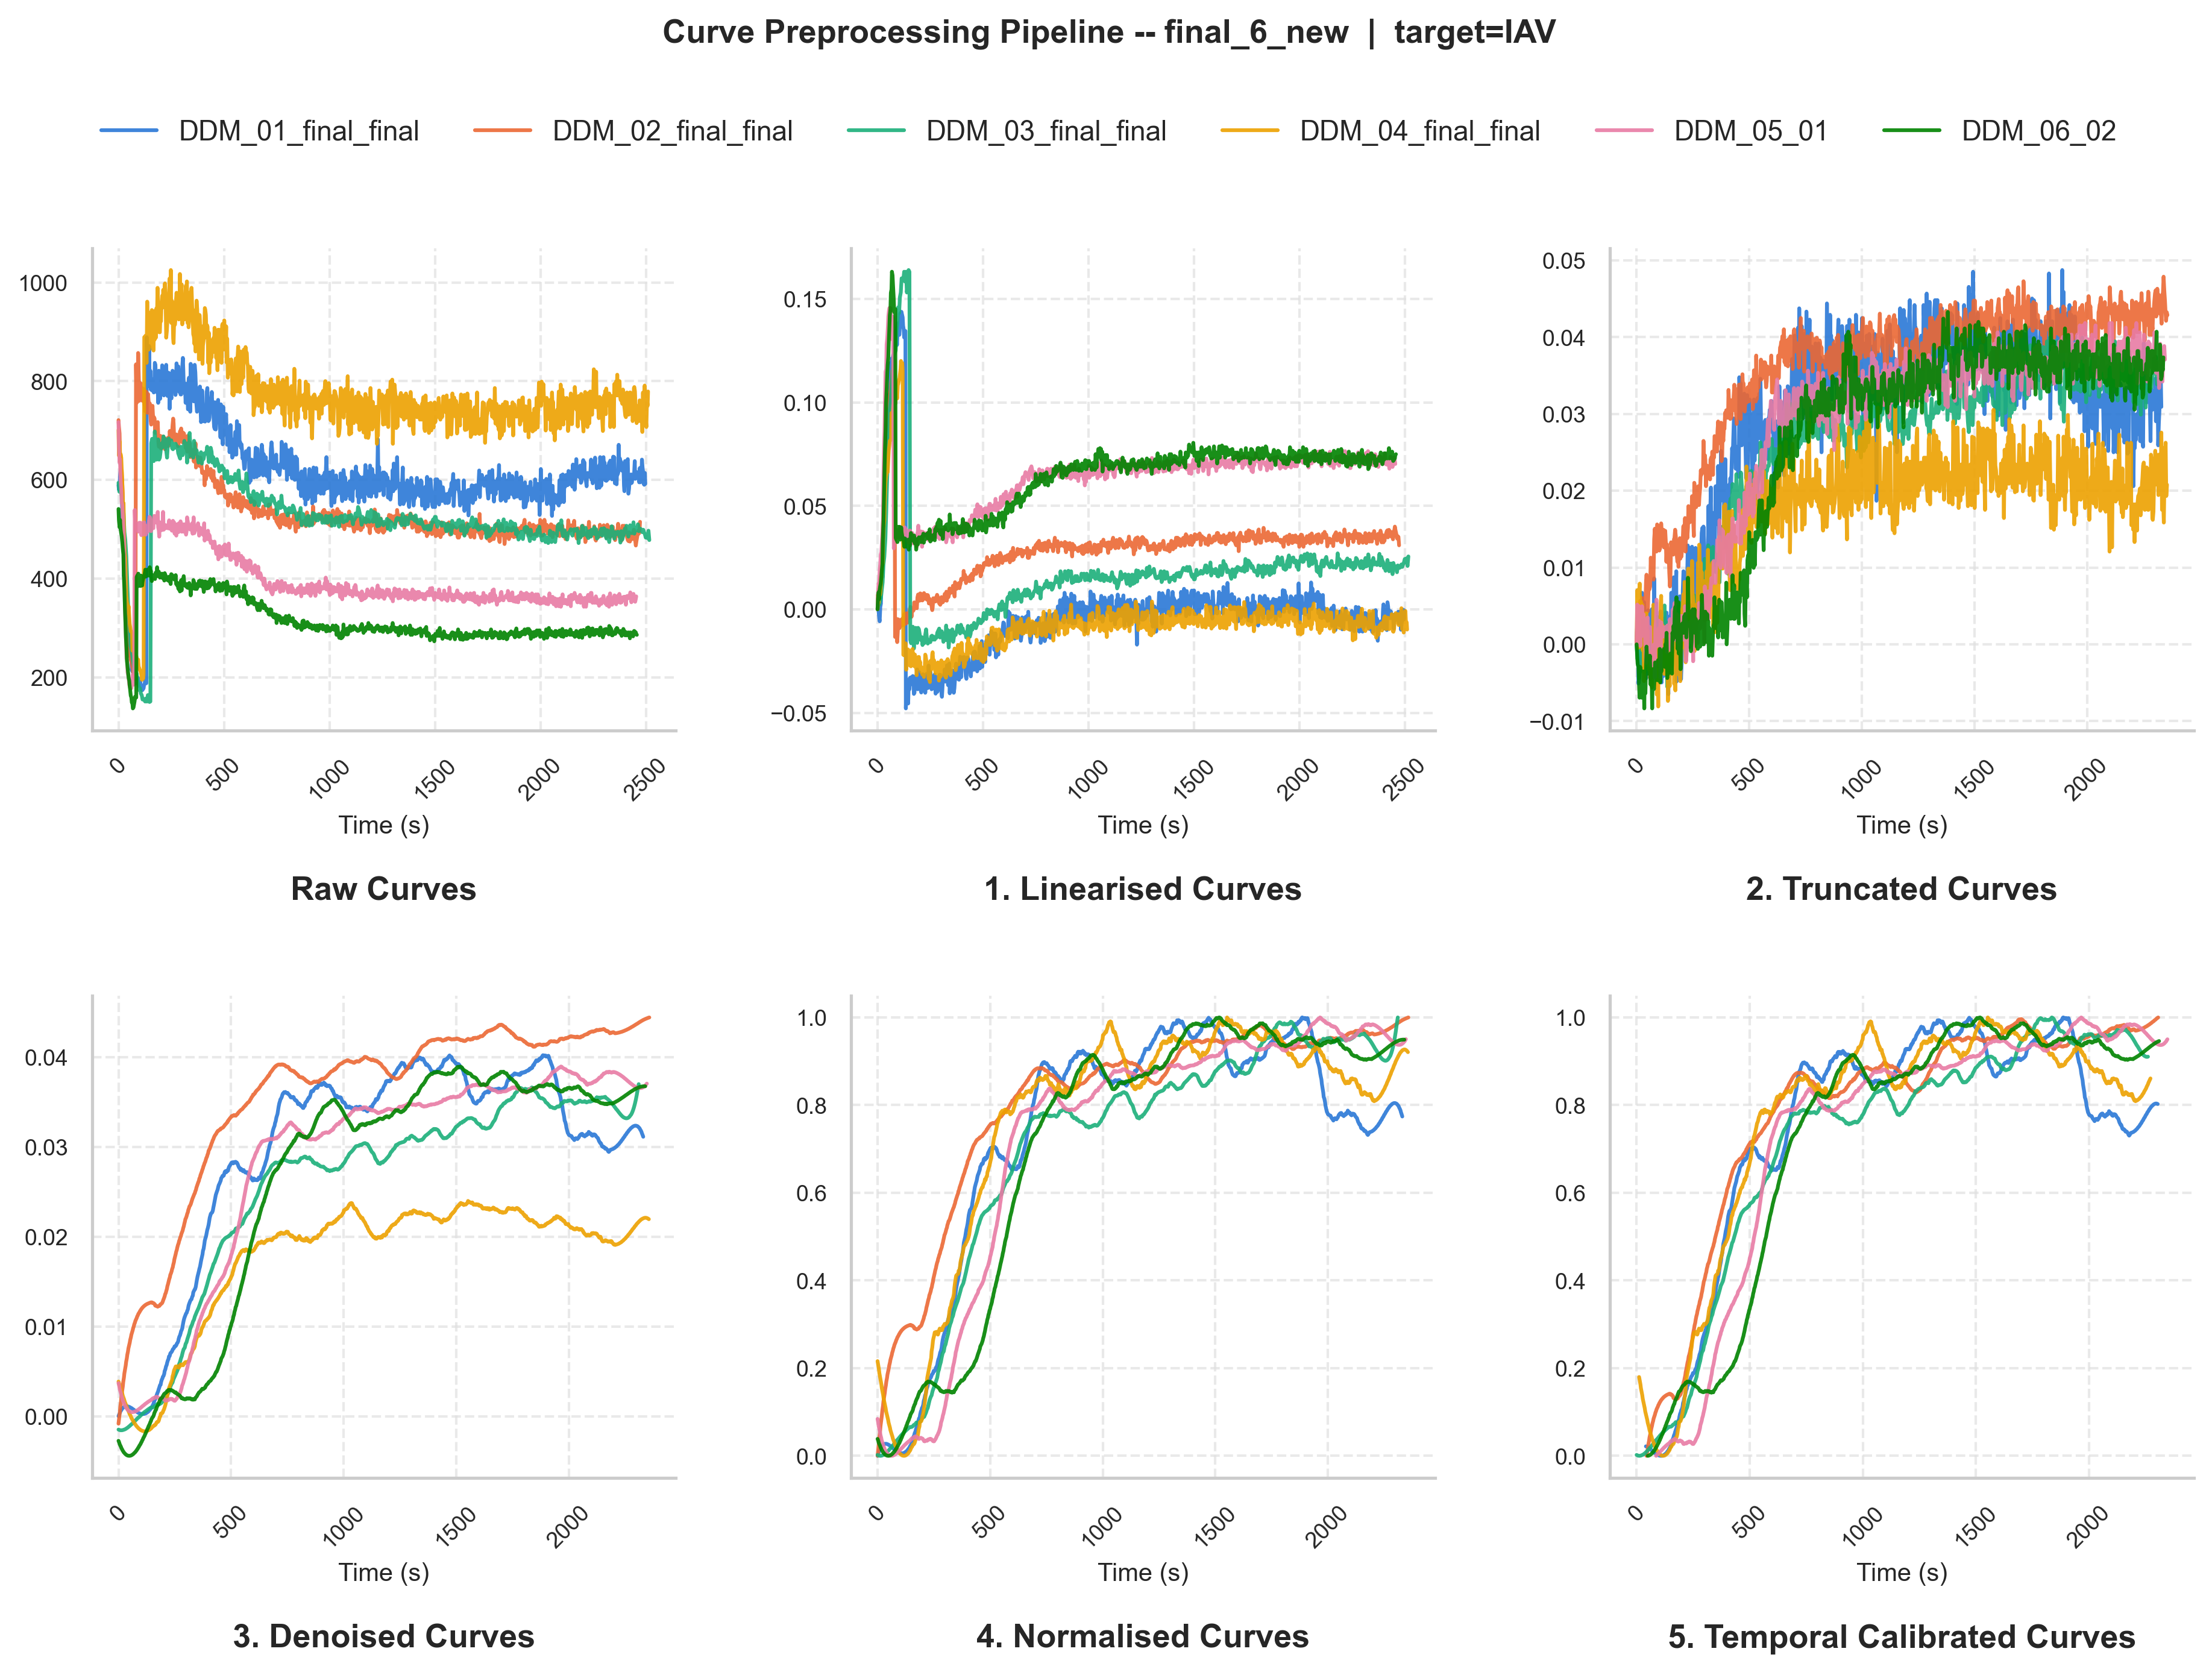

In [ ]:
%matplotlib inline
STAGE_SPECS = [
    ('Raw Curves',                     't_full',  'raw'),
    ('1. Linearised Curves',           't_full',  'lin'),
    ('2. Truncated Curves',            't_trunc', 'trunc'),
    ('3. Denoised Curves',             't_trunc', 'denoised'),
    ('4. Normalised Curves',           't_trunc', 'normalised'),
    ('5. Temporal Calibrated Curves',  None,      'calibrated'),
]

_PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
chip_colors = {name: _PALETTE[i % len(_PALETTE)] for i, name in enumerate(chip_names)}

def short_chip_name(name):
    return name.split('_U_', 1)[1]

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5), dpi=300)
axes = axes.flatten()
fig.subplots_adjust(wspace=0.3, hspace=0.55, bottom=0.08, top=0.88)

for ax, (caption, t_key, y_key) in zip(axes, STAGE_SPECS):
    for name in chip_names:
        if y_key == 'calibrated':
            t, y = calibrated[name]
        else:
            t, y = per_chip_results[name][t_key], per_chip_results[name][y_key]
        if y_key == 'lin':
            y = y - y[0]
        ax.plot(t, y, color=chip_colors[name], lw=1.5, alpha=0.9, label=short_chip_name(name))
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.tick_params(labelsize=9)
    ax.tick_params(axis='x', rotation=45)

fig.canvas.draw()

renderer = fig.canvas.get_renderer()
for ax, (caption, _, _) in zip(axes, STAGE_SPECS):
    pos = ax.get_position()
    tb = ax.get_tightbbox(renderer).transformed(fig.transFigure.inverted())
    fig.text((pos.x0 + pos.x1) / 2, tb.y0 - 0.025, caption, ha='center', va='top',
             fontsize=13, fontweight='bold')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(chip_names),
          bbox_to_anchor=(0.5, 0.98), fontsize=11, frameon=False)
fig.suptitle(f'Curve Preprocessing Pipeline -- {LOFO_GROUP}  |  target={TARGET_LABEL}',
            fontsize=13, fontweight='bold', y=1.03)

SAVE_DIR = Path('figures')
SAVE_DIR.mkdir(exist_ok=True)
# save_path = SAVE_DIR / f'{LOFO_GROUP}_{TARGET_LABEL}_multi_chip_pipeline.png'
# fig.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
# print(f"Saved high-res figure -> {save_path.resolve()}")
plt.show()